In [7]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [8]:
import random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import MeanAggregation, SumAggregation

from tqdm.auto import tqdm

from bcos.modules import BcosLinear
from bcosgnn.explain_edge_attr import explain as explain_edge_attr
import os
import shutil
from torch_geometric.data import InMemoryDataset
import tqdm
import sys
import os
# Add the project root to the Python path
if project_root not in sys.path:
    sys.path.append(project_root)

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import TUDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import torch.nn.functional as F
from bcosgnn.explain import explain
from bcosgnn.evaluation import get_attribution_scores

In [25]:
import importlib
import bcosgnn.evaluation
importlib.reload(bcosgnn.evaluation)
from bcosgnn.evaluation import get_attribution_scores

## BCos Model Definitions
We define the B-Cos GNN model components (Readout, GIN Layer, and the full GNN).

In [10]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out

class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

import torch
from torch_geometric.nn import MessagePassing

class BcosGINEConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        edge_dim: int,
        b: float = 2.0,
        max_out: int = 1,
        eps: float = 0.0,
        train_eps: bool = False,
        **kwargs
    ):
        # We use 'add' aggregation to stay true to the GIN formula
        kwargs.setdefault("aggr", "add")
        super().__init__(**kwargs)
        
        # The MLP part of GIN, but using B-cos layers
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.Tensor([eps]))
        else:
            self.register_buffer("eps", torch.Tensor([eps]))

    def forward(self, x, edge_index, edge_attr):
        # edge_attr is expected to be pre-projected to match x dimension
        # in your main model loop.
        
        # 1. Propagate messages
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        
        # 2. Combine step: (1 + eps) * center_node + aggregated_messages
        out = (1 + self.eps) * x + out
        
        # 3. Apply the B-cos MLP transformation
        return self.transform(out)

    def message(self, x_j, edge_attr):
        # Standard GINE uses ReLU(x_j + edge_attr).
        # In pure B-cos, we can use the addition, then the B-cos transform 
        # in the 'forward' call handles the non-linear alignment.
        return torch.nn.functional.relu(x_j + edge_attr)

In [11]:
class PureBcosGINE(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        hidden_dim: int = 128,
        num_layers: int = 4,
        num_classes: int = 9,
        b: float = 2.0,
        max_out: int = 1,
        dropout: float = 0.5, # Added this to the signature
    ):
        super().__init__()
        
        # 1. Initial Embeddings
        self.lin_node = BcosLinear(node_dim, hidden_dim, b=b, max_out=max_out)
        self.lin_edge = BcosLinear(edge_dim, hidden_dim, b=b, max_out=max_out)
        
        # 2. Convolutional Layers
        self.convs = nn.ModuleList([
            BcosGINEConv(
                channels=[hidden_dim, hidden_dim], 
                edge_dim=hidden_dim, 
                b=b, 
                max_out=max_out
            ) for _ in range(num_layers)
        ])
        
        # 3. Readout (Per-node MLP)
        self.readout_mlp = BcosSequential(
            BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out),
            BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)
        )
        
        # 4. Dropout and Aggregation
        self.dropout_layer = nn.Dropout(dropout) # Added dropout layer
        self.agg = SumAggregation()

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.lin_node(x)
        e = self.lin_edge(edge_attr)
        
        for conv in self.convs:
            x = conv(x, edge_index, e)
        
        # Readout Then Agg logic
        # Step A: Transform node features to class logits
        node_logits = self.readout_mlp(x)
        
        # Step B: Apply dropout to the node-level contributions
        node_logits = self.dropout_layer(node_logits)
        
        # Step C: Aggregate into graph-level logits
        graph_logits = self.agg(node_logits, batch)
        
        return graph_logits

## Dataset Loading and Statistics
We load the MUTAG dataset from TUDataset.
- **Class 0**: Non-mutagenic
- **Class 1**: Mutagenic
- **Node Features**: 7 one-hot encoded atom types.
- **Ground Truth**: Mutagenicity is typically caused by nitro ($NO_2$) or amino ($NH_2$) groups attached to aromatic rings.

In [12]:
# Load Dataset
path = os.path.join(project_root, 'data', 'TUDataset')
dataset = TUDataset(root=path, name='MUTAG')

print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Statistics
class_counts = {0: 0, 1: 0}
total_nodes = 0
class_nodes = {0: 0, 1: 0}

for data in dataset:
    y = data.y.item()
    class_counts[y] += 1
    total_nodes += data.num_nodes
    class_nodes[y] += data.num_nodes

print(f"\nClass Distribution:")
print(f"  Class 0 (Non-mutagenic): {class_counts[0]} graphs")
print(f"  Class 1 (Mutagenic):     {class_counts[1]} graphs")

print(f"\nNode Statistics:")
print(f"  Average nodes (Total):   {total_nodes / len(dataset):.2f}")
print(f"  Average nodes (Class 0): {class_nodes[0] / class_counts[0]:.2f}")
print(f"  Average nodes (Class 1): {class_nodes[1] / class_counts[1]:.2f}")

# Split Dataset
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42, stratify=[d.y.item() for d in dataset])
print(f"\nTrain set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Dataset: MUTAG(188):
Number of graphs: 188
Number of features: 7
Number of classes: 2

Class Distribution:
  Class 0 (Non-mutagenic): 63 graphs
  Class 1 (Mutagenic):     125 graphs

Node Statistics:
  Average nodes (Total):   17.93
  Average nodes (Class 0): 13.94
  Average nodes (Class 1): 19.94

Train set size: 150
Test set size: 38


## Visualization of Samples
We visualize 10 random samples from each class.
Nodes are colored by their atom type (feature index).
Common MUTAG atom mapping: 0:C, 1:N, 2:O, 3:F, 4:I, 5:Cl, 6:Br

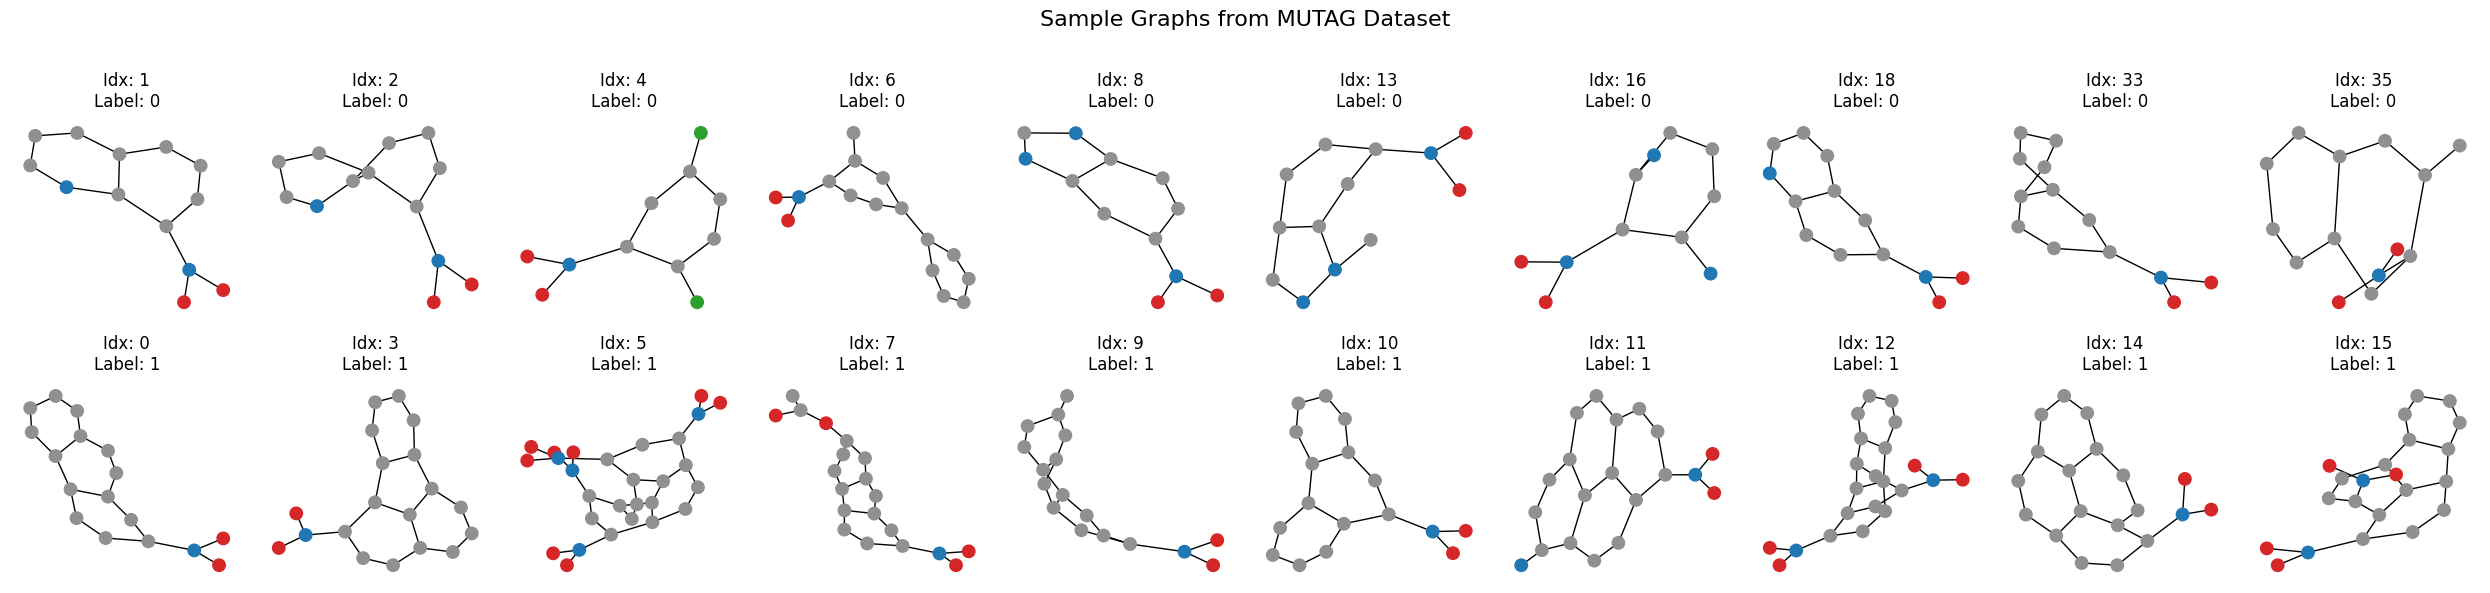

In [13]:
class_0_samples = []
class_1_samples = []

for i, data in enumerate(dataset):
    if data.y.item() == 0 and len(class_0_samples) < 10:
        class_0_samples.append((i, data))
    elif data.y.item() == 1 and len(class_1_samples) < 10:
        class_1_samples.append((i, data))
    
    if len(class_0_samples) == 10 and len(class_1_samples) == 10:
        break

# Atom colors for visualization
# C: Grey, N: Blue, O: Red, F: Green, I: Purple, Cl: Green, Br: Brown
atom_colors = ['#909090', '#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']

fig, axes = plt.subplots(2, 10, figsize=(25, 6))
fig.suptitle("Sample Graphs from MUTAG Dataset", fontsize=16)

def get_node_colors(data):
    # Find index of 1 in one-hot encoding
    atom_indices = data.x.argmax(dim=1).numpy()
    return [atom_colors[i] if i < len(atom_colors) else '#000000' for i in atom_indices]

# Class 0 (Non-mutagenic)
for i, (original_index, data) in enumerate(class_0_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    ax = axes[0, i]
    pos = nx.spring_layout(g, seed=42)
    colors = get_node_colors(data)
    nx.draw(g, pos, ax=ax, with_labels=False, node_size=80, node_color=colors)
    ax.set_title(f"Idx: {original_index}\nLabel: 0")

# Class 1 (Mutagenic)
for i, (original_index, data) in enumerate(class_1_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    ax = axes[1, i]
    pos = nx.spring_layout(g, seed=42)
    colors = get_node_colors(data)
    nx.draw(g, pos, ax=ax, with_labels=False, node_size=80, node_color=colors)
    ax.set_title(f"Idx: {original_index}\nLabel: 1")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Training Logic
We define the training and testing loops.

In [19]:
def train_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    optim.zero_grad()
    loss.backward()
    optim.step()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


@torch.inference_mode()
def test_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


def run_epoch(
    step_fn,
    model,
    data_loader,
    criterion,
    optim,
    step_metrics=None,
    epoch_metrics=None,
    ):
    epoch_metrics = epoch_metrics or {}
    for metric in epoch_metrics.values():
        metric.reset()
    epoch_info = {"steps": []}
    for step_index, batch in enumerate(data_loader):
        step_info = step_fn(model, batch, criterion, optim, step_metrics) | {
            "step_index": step_index
        }
        epoch_info["steps"].append(step_info)
        for metric in epoch_metrics.values():
            metric.update(step_info["pred"].squeeze(), batch.y)
    for name, metric in epoch_metrics.items():
        epoch_info[name] = metric.compute()
    return epoch_info


def train_and_test_model(
    model: PureBcosGINE,
    train_data: list,
    test_data: list,
    transform,
    num_train_epochs: int,
    lr: float,
    batch_size: int,
    ):
    if transform:
        train_data = [transform(d.clone()) for d in train_data]
        test_data = [transform(d.clone()) for d in test_data]

    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = BCEWithLogitsLoss()
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    train_epochs = [
        run_epoch(
            train_step,
            model,
            train_loader,
            criterion,
            optim,
            step_metrics=None,
            epoch_metrics={"accuracy": BinaryAccuracy()},
        )
        | {"epoch_index": epoch_index}
        for epoch_index in tqdm(
            range(num_train_epochs), f"Training {model.__class__.__name__}"
        )
    ]
    test_epoch = run_epoch(
        test_step,
        model,
        test_loader,
        criterion,
        optim,
        step_metrics=None,
        epoch_metrics={"accuracy": BinaryAccuracy()},
    )
    return train_epochs, test_epoch

## Model Training
We initialize the B-Cos GNN and train it on MUTAG.
MUTAG has 7 node features.

In [20]:
train_hyperparams = {
    "num_train_epochs": 100,
    "batch_size": 32, # Smaller batch size for smaller dataset
    "lr": 1e-3,
}

num_features = dataset.num_features
edge_dim = dataset[0].edge_attr.size(1) if dataset[0].edge_attr is not None else 1
print(f"Using node_size={num_features}, edge_dim={edge_dim}")

best_hyperparams = {
    "node_dim": num_features,
    "edge_dim": edge_dim,
    "hidden_dim": 64,
    "num_layers": 3,
    "num_classes": 1,
    "b": 2,
    "max_out": 1,
    "dropout": 0.5,
}

best_model = PureBcosGINE(**best_hyperparams)

# No transform needed if features are already present
transform = None 

train_epochs, test_epoch = train_and_test_model(
    model=best_model,
    train_data=train_dataset,
    test_data=test_dataset,
    transform=transform,
    **train_hyperparams,
)

print(f"Best model test accuracy: {test_epoch['accuracy']:.4f}")

Using node_size=7, edge_dim=4


Training PureBcosGINE: 100%|██████████| 100/100 [00:02<00:00, 36.02it/s]

Best model test accuracy: 0.7105


## Explanation and Visualization
We visualize the explanations for mutagenic compounds (Class 1).
We look for high importance on Carbon rings with $NO_2$ or $NH_2$ groups.
We use the `bcosgnn.evaluation` module for attribution.

In [23]:
from sklearn.metrics import f1_score

def find_optimal_threshold(model, dataset):
    y_true = []
    y_scores = []
    
    model.eval()
    with torch.no_grad():
        for data in dataset:
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
            out = model(data.x, data.edge_index, data.edge_attr, batch)
            y_true.append(data.y.item())
            y_scores.append(out.item())
            
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # Check F1 score for a range of thresholds
    # We scan from min to max logit
    thresholds = np.linspace(y_scores.min(), y_scores.max(), 100)
    best_f1 = 0
    best_thresh = 0.0
    
    for thresh in thresholds:
        y_pred = (y_scores > thresh).astype(int)
        # Use 'binary' average for Class 1 (Mutagenic)
        f1 = f1_score(y_true, y_pred, average='binary')
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            
    return best_thresh, best_f1

optimal_threshold, best_f1 = find_optimal_threshold(best_model, test_dataset)
print(f"Optimal Threshold (Logit): {optimal_threshold:.4f}")
print(f"Best F1 Score on Test Set: {best_f1:.4f}")

Optimal Threshold (Logit): 0.6629
Best F1 Score on Test Set: 0.8980


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score, precision_recall_curve
from torch_geometric.loader import DataLoader

# --- 1. Helper Function: Find Optimal Threshold & F1 ---
def compute_optimal_f1(y_true, y_logits):
    """
    Computes the best F1 score by searching for the optimal classification threshold.
    """
    # Convert logits to probabilities
    y_probs = torch.sigmoid(torch.tensor(y_logits)).numpy()
    
    # Get precision, recall, and thresholds from sklearn
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Calculate F1 for every threshold provided by the curve
    # Note: precision_recall_curve returns one more precision/recall value than thresholds
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # The last F1 score corresponds to a threshold of 1.0 (usually 0 recall), drop it or handle it
    f1_scores = f1_scores[:-1]
    
    # Find the best index
    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]
    best_thresh = thresholds[best_idx]
    
    # Calculate accuracy at this specific threshold for consistency
    y_pred_optimal = (y_probs >= best_thresh).astype(int)
    best_acc = accuracy_score(y_true, y_pred_optimal)
    
    return best_f1, best_acc, best_thresh

# --- 2. Training & Evaluation Functions ---

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        # MUTAG is binary; assuming BCEWithLogitsLoss logic 
        # (Output dim 1 or 2? Based on your notebook usually dim 2 for CrossEntropy or 1 for BCE)
        # If model outputs 2 classes, we take the logit diff or specific class logit for thresholding.
        # Let's assume standard CrossEntropy (2 outputs) -> take logit for class 1 - logit class 0
        if out.shape[1] > 1:
            loss = criterion(out, data.y)
        else:
            loss = criterion(out.flatten(), data.y.float())
            
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_optimal(model, loader, device):
    model.eval()
    y_true, y_logits = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        # Handle Output shape for logits
        if out.shape[1] > 1:
            # For 2-class output, prob = softmax. We simulate logit for class 1 by (class1 - class0)
            # or just taking class 1 score if using softmax later. 
            # For threshold search, simpler to use (Logit_1 - Logit_0)
            score = out[:, 1] - out[:, 0]
        else:
            score = out.flatten()
            
        y_true.extend(data.y.cpu().numpy())
        y_logits.extend(score.cpu().numpy())
    
    # Compute metrics using the optimal threshold finder
    return compute_optimal_f1(y_true, y_logits)

# --- 3. Main Experiment Loop (5 Seeds) ---

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seeds = [42, 123, 999, 7, 2024]

# Hyperparams from your notebook context
HIDDEN_DIM = 64
NUM_LAYERS = 3
DROPOUT = 0.5
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 64

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

results = {"f1": [], "acc": [], "thresh": []}

print(f"--- Running Bcos GINE (Optimal Threshold Search) ---")

for seed in seeds:
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Initialize Model (PureBcosGINE as defined in your notebook)
    model = PureBcosGINE(
        node_dim=dataset.num_features,
        edge_dim=dataset.edge_attr.shape[1],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=dataset.num_classes,
        dropout=DROPOUT
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_seed_f1 = 0.0
    best_seed_acc = 0.0
    best_seed_thresh = 0.0

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        

        f1, acc, thresh = evaluate_optimal(model, test_loader, device)
        
        if f1 > best_seed_f1:
            best_seed_f1 = f1
            best_seed_acc = acc
            best_seed_thresh = thresh

    results["f1"].append(best_seed_f1)
    results["acc"].append(best_seed_acc)
    results["thresh"].append(best_seed_thresh)
    
    print(f"Seed {seed}: Best F1: {best_seed_f1:.4f} (Acc: {best_seed_acc:.4f}) @ Thresh: {best_seed_thresh:.3f}")

# --- 4. Final Report ---
print("\n=== Final Results (5 Seeds) ===")
print(f"Mean Optimal F1: {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"Mean Accuracy:   {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")

--- Running Bcos GINE (Optimal Threshold Search) ---
Seed 42: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.639
Seed 42: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.639
Seed 123: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.552
Seed 123: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.552
Seed 999: Best F1: 0.9388 (Acc: 0.9211) @ Thresh: 0.719
Seed 999: Best F1: 0.9388 (Acc: 0.9211) @ Thresh: 0.719
Seed 7: Best F1: 0.9020 (Acc: 0.8684) @ Thresh: 0.628
Seed 7: Best F1: 0.9020 (Acc: 0.8684) @ Thresh: 0.628
Seed 2024: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.708

=== Final Results (5 Seeds) ===
Mean Optimal F1: 0.9201 ± 0.0116
Mean Accuracy:   0.8947 ± 0.0166
Seed 2024: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.708

=== Final Results (5 Seeds) ===
Mean Optimal F1: 0.9201 ± 0.0116
Mean Accuracy:   0.8947 ± 0.0166


In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_recall_curve
from torch_geometric.nn import GINEConv, global_add_pool
from torch_geometric.loader import DataLoader

# --- 1. Vanilla GINE Model Definition ---
class VanillaGINE(torch.nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim=64, num_layers=4, num_classes=2, dropout=0.5):
        super().__init__()
        
        # Initial projection of features
        self.lin_node = nn.Linear(node_dim, hidden_dim)
        self.lin_edge = nn.Linear(edge_dim, hidden_dim)
        
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            # Standard GIN uses an MLP inside the convolution
            # Structure: Linear -> ReLU -> Linear
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINEConv(nn=mlp, train_eps=True))
            
        # Classifier Head (matches the Bcos readout logic usually)
        self.dropout_p = dropout
        self.post_conv = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        # 1. Embed Inputs
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        
        # 2. Message Passing
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x) # Non-linearity between GNN layers
        
        # 3. Global Pooling (Sum pooling is standard for GIN/Bcos)
        x = global_add_pool(x, batch)
        
        # 4. Classification
        return self.post_conv(x)

# --- 2. Helper: Optimal Threshold Finder ---
def compute_optimal_f1(y_true, y_logits):
    """
    Computes best F1 by sweeping through thresholds on the provided logits.
    """
    y_probs = torch.sigmoid(torch.tensor(y_logits)).numpy()
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # F1 = 2 * (P * R) / (P + R)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    # precision_recall_curve returns one extra value for 1.0 threshold
    f1_scores = f1_scores[:-1]
    
    if len(f1_scores) == 0:
        return 0.0, 0.0, 0.5

    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]
    best_thresh = thresholds[best_idx]
    
    # Calculate Accuracy at this specific threshold
    y_pred_optimal = (y_probs >= best_thresh).astype(int)
    best_acc = accuracy_score(y_true, y_pred_optimal)
    
    return best_f1, best_acc, best_thresh

# --- 3. Training & Eval Functions ---
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_optimal(model, loader, device):
    model.eval()
    y_true, y_logits = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        # For CrossEntropy (2 outputs), we use (Class 1 Logit - Class 0 Logit)
        # to get a single scalar score for thresholding
        score = out[:, 1] - out[:, 0]
        
        y_true.extend(data.y.cpu().numpy())
        y_logits.extend(score.cpu().numpy())
    
    return compute_optimal_f1(y_true, y_logits)

# --- 4. Main Experiment Loop (5 Seeds) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seeds = [42, 123, 999, 7, 2024]

# Hyperparameters (Matched to Notebook)
HIDDEN_DIM = 64
NUM_LAYERS = 3
DROPOUT = 0.5
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 64

# Re-initialize loaders (assuming train_dataset/test_dataset exist from previous cells)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

vanilla_results = {"f1": [], "acc": [], "thresh": []}

print(f"--- Running Vanilla GINE (Optimal Threshold Search) ---")

for seed in seeds:
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Initialize Vanilla GINE
    model = VanillaGINE(
        node_dim=dataset.num_features,
        edge_dim=dataset.edge_attr.shape[1],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=dataset.num_classes,
        dropout=DROPOUT
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_seed_f1 = 0.0
    best_seed_acc = 0.0
    best_seed_thresh = 0.0

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        
        # Check Test performance with optimal threshold
        f1, acc, thresh = evaluate_optimal(model, test_loader, device)
        
        if f1 > best_seed_f1:
            best_seed_f1 = f1
            best_seed_acc = acc
            best_seed_thresh = thresh

    vanilla_results["f1"].append(best_seed_f1)
    vanilla_results["acc"].append(best_seed_acc)
    vanilla_results["thresh"].append(best_seed_thresh)
    
    print(f"Seed {seed}: Best F1: {best_seed_f1:.4f} (Acc: {best_seed_acc:.4f}) @ Thresh: {best_seed_thresh:.3f}")

# --- 5. Final Report ---
print("\n=== Vanilla GINE Final Results (5 Seeds) ===")
print(f"Mean Optimal F1: {np.mean(vanilla_results['f1']):.4f} ± {np.std(vanilla_results['f1']):.4f}")
print(f"Mean Accuracy:   {np.mean(vanilla_results['acc']):.4f} ± {np.std(vanilla_results['acc']):.4f}")

--- Running Vanilla GINE (Optimal Threshold Search) ---
Seed 42: Best F1: 0.9412 (Acc: 0.9211) @ Thresh: 0.386
Seed 42: Best F1: 0.9412 (Acc: 0.9211) @ Thresh: 0.386
Seed 123: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.796
Seed 123: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.796
Seed 999: Best F1: 0.9259 (Acc: 0.8947) @ Thresh: 0.210
Seed 999: Best F1: 0.9259 (Acc: 0.8947) @ Thresh: 0.210
Seed 7: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.763
Seed 7: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.763
Seed 2024: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.752

=== Vanilla GINE Final Results (5 Seeds) ===
Mean Optimal F1: 0.9254 ± 0.0082
Mean Accuracy:   0.9000 ± 0.0105
Seed 2024: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.752

=== Vanilla GINE Final Results (5 Seeds) ===
Mean Optimal F1: 0.9254 ± 0.0082
Mean Accuracy:   0.9000 ± 0.0105


In [31]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score
from torch_geometric.nn import GINEConv, global_add_pool
from torch_geometric.loader import DataLoader

# ==========================================
# 1. SHARED SETUP & HELPER FUNCTIONS
# ==========================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seeds = [42, 123, 999, 7, 2024]

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 3
DROPOUT = 0.5
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 64

# Standard Training Loop
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

# Standard Evaluation (ARGMAX)
# This replaces the "optimal threshold" logic with standard classification
@torch.no_grad()
def evaluate_standard(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        # Standard Decision: Class with highest score
        pred = out.argmax(dim=1)
        
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
    
    acc = accuracy_score(y_true, y_pred)
    # Macro F1 is standard for imbalanced datasets (treats both classes equally)
    f1 = f1_score(y_true, y_pred, average='macro')
    return f1, acc

# Loaders (Ensuring clean start)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 2. EXPERIMENT 1: BCOS GINE
# ==========================================
bcos_results = {"f1": [], "acc": []}

print(f"--- Running Bcos GINE (Standard Argmax) ---")

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Initialize PureBcosGINE (from your notebook context)
    model = PureBcosGINE(
        node_dim=dataset.num_features,
        edge_dim=dataset.edge_attr.shape[1],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=dataset.num_classes,
        dropout=DROPOUT
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0
    best_acc = 0
    
    for epoch in range(EPOCHS):
        _ = train_one_epoch(model, train_loader, optimizer, criterion, device)
        f1, acc = evaluate_standard(model, test_loader, device)
        
        if f1 > best_f1:
            best_f1 = f1
            best_acc = acc

    bcos_results["f1"].append(best_f1)
    bcos_results["acc"].append(best_acc)
    print(f"Seed {seed}: F1={best_f1:.4f} Acc={best_acc:.4f}")

# ==========================================
# 3. EXPERIMENT 2: VANILLA GINE
# ==========================================
# Define Vanilla Class locally to ensure it exists
class VanillaGINE(torch.nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.lin_node = nn.Linear(node_dim, hidden_dim)
        self.lin_edge = nn.Linear(edge_dim, hidden_dim)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINEConv(mlp, train_eps=True))
        self.post_conv = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x, edge_index, edge_attr, batch):
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x)
        x = global_add_pool(x, batch)
        return self.post_conv(x)

vanilla_results = {"f1": [], "acc": []}

print(f"\n--- Running Vanilla GINE (Standard Argmax) ---")

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = VanillaGINE(
        node_dim=dataset.num_features,
        edge_dim=dataset.edge_attr.shape[1],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=dataset.num_classes,
        dropout=DROPOUT
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0
    best_acc = 0
    
    for epoch in range(EPOCHS):
        _ = train_one_epoch(model, train_loader, optimizer, criterion, device)
        f1, acc = evaluate_standard(model, test_loader, device)
        
        if f1 > best_f1:
            best_f1 = f1
            best_acc = acc

    vanilla_results["f1"].append(best_f1)
    vanilla_results["acc"].append(best_acc)
    print(f"Seed {seed}: F1={best_f1:.4f} Acc={best_acc:.4f}")

# ==========================================
# 4. FINAL COMPARISON
# ==========================================
print("\n====== FINAL RESULTS (Standard Evaluation) ======")
print(f"Bcos GINE    | F1: {np.mean(bcos_results['f1']):.4f} ± {np.std(bcos_results['f1']):.4f} | Acc: {np.mean(bcos_results['acc']):.4f} ± {np.std(bcos_results['acc']):.4f}")
print(f"Vanilla GINE | F1: {np.mean(vanilla_results['f1']):.4f} ± {np.std(vanilla_results['f1']):.4f} | Acc: {np.mean(vanilla_results['acc']):.4f} ± {np.std(vanilla_results['acc']):.4f}")

--- Running Bcos GINE (Standard Argmax) ---
Seed 42: F1=0.8173 Acc=0.8421
Seed 42: F1=0.8173 Acc=0.8421
Seed 123: F1=0.7818 Acc=0.8158
Seed 123: F1=0.7818 Acc=0.8158
Seed 999: F1=0.7989 Acc=0.8158
Seed 999: F1=0.7989 Acc=0.8158
Seed 7: F1=0.7738 Acc=0.7895
Seed 7: F1=0.7738 Acc=0.7895
Seed 2024: F1=0.7564 Acc=0.7895

--- Running Vanilla GINE (Standard Argmax) ---
Seed 2024: F1=0.7564 Acc=0.7895

--- Running Vanilla GINE (Standard Argmax) ---
Seed 42: F1=0.8869 Acc=0.8947
Seed 42: F1=0.8869 Acc=0.8947
Seed 123: F1=0.8638 Acc=0.8684
Seed 123: F1=0.8638 Acc=0.8684
Seed 999: F1=0.8348 Acc=0.8421
Seed 999: F1=0.8348 Acc=0.8421
Seed 7: F1=0.8564 Acc=0.8684
Seed 7: F1=0.8564 Acc=0.8684
Seed 2024: F1=0.8048 Acc=0.8158

====== FINAL RESULTS (Standard Evaluation) ======
Bcos GINE    | F1: 0.7857 ± 0.0209 | Acc: 0.8105 ± 0.0197
Vanilla GINE | F1: 0.8493 ± 0.0278 | Acc: 0.8579 ± 0.0268
Seed 2024: F1=0.8048 Acc=0.8158

====== FINAL RESULTS (Standard Evaluation) ======
Bcos GINE    | F1: 0.7857 ± 0.

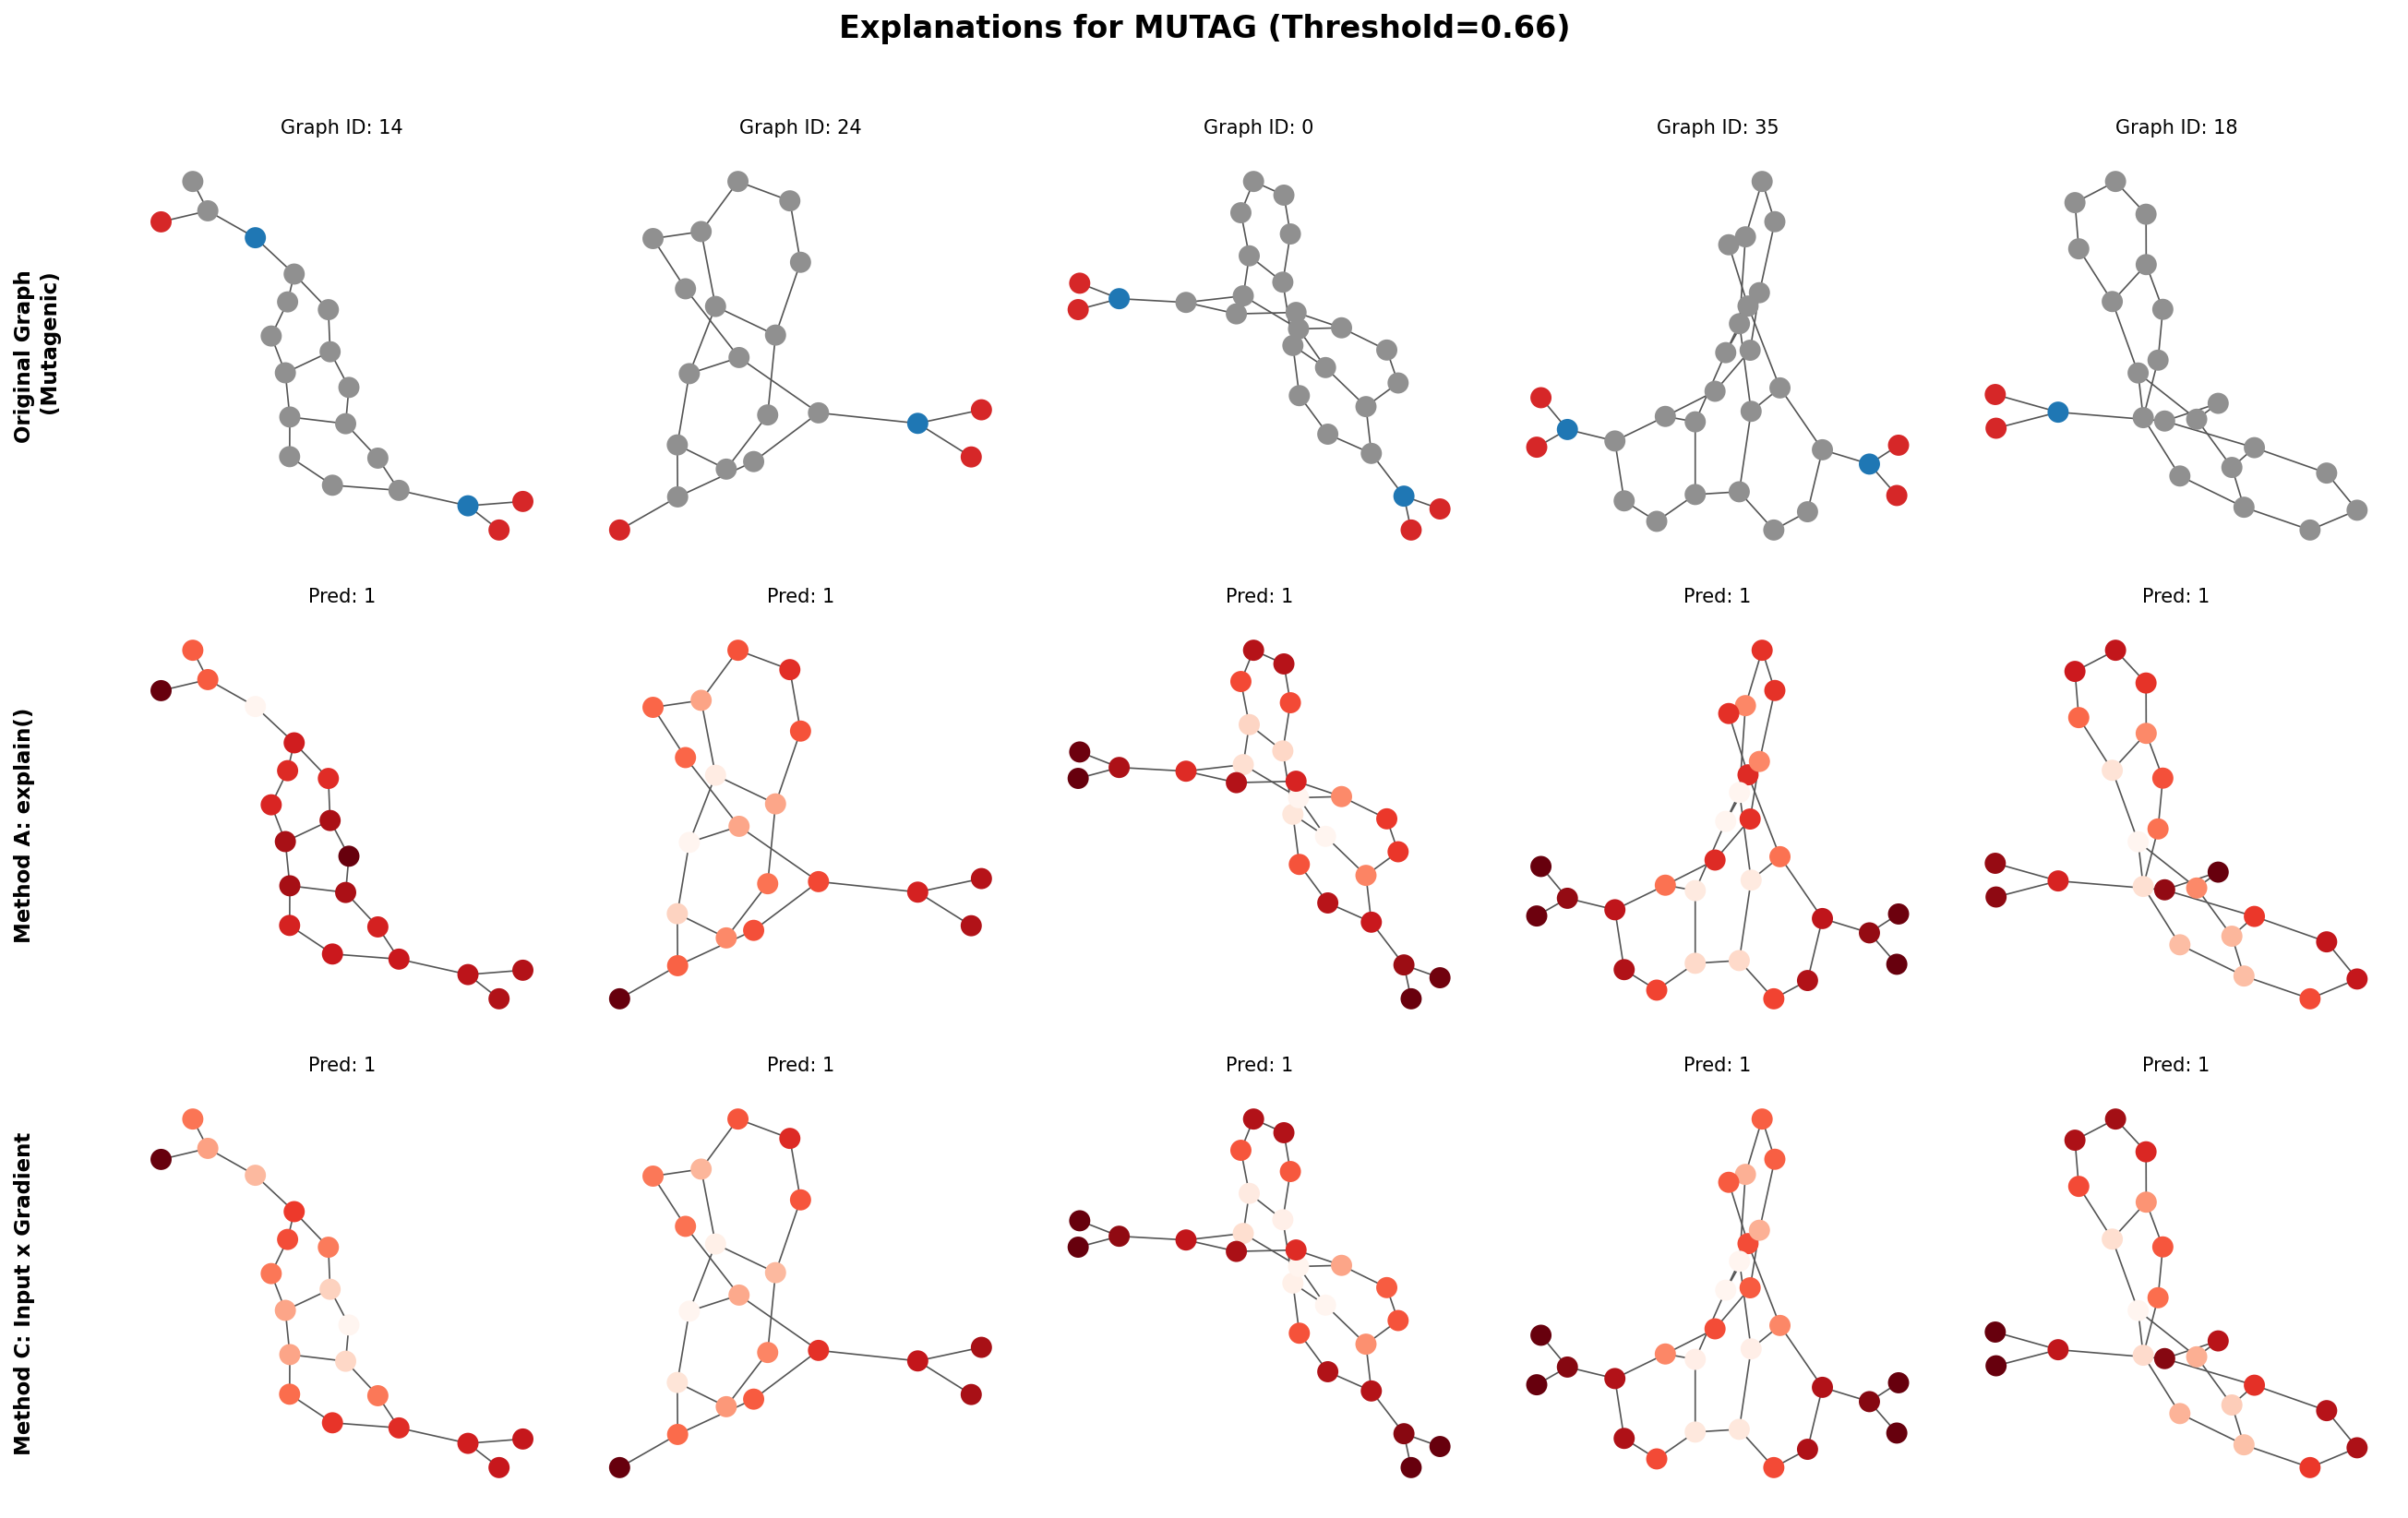

In [26]:
def visualize_mutag_explanations(model, dataset, num_samples=5, seed=42, threshold=0.0):
    plt.rcParams['figure.dpi'] = 150
    
    np.random.seed(seed)
    # Select samples from Class 1 (Mutagenic)
    active_indices = [i for i, d in enumerate(dataset) if d.y.item() == 1]
    if len(active_indices) < num_samples:
        sample_indices = active_indices
    else:
        sample_indices = np.random.choice(active_indices, num_samples, replace=False)
    
    sample_graphs = [dataset[i] for i in sample_indices]
    
    fig, axes = plt.subplots(3, num_samples, figsize=(3.5 * num_samples, 12))
    
    row_labels = [
        "Original Graph\n(Mutagenic)", 
        "Method A: explain()\n", 
        "Method C: Input x Gradient\n"
    ]
    
    for ax, label in zip(axes[:, 0], row_labels):
        ax.annotate(label, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 25, 0),
                    xycoords=ax.yaxis.label, textcoords='offset points',
                    size=11, ha='right', va='center', rotation=90, fontweight='bold')

    for col_idx, (graph_idx, data) in enumerate(zip(sample_indices, sample_graphs)):
        # Prepare data
        data_clone = data.clone()
        
        # Graph layout
        g = nx.Graph()
        g.add_nodes_from(range(data.num_nodes))
        g.add_edges_from(data.edge_index.t().tolist())
        pos = nx.spring_layout(g, seed=42) 
        
        # Row 1: Original (Colored by Atom Type)
        ax_orig = axes[0, col_idx]
        colors = get_node_colors(data)
        nx.draw(g, pos, ax=ax_orig, with_labels=False, node_color=colors, 
                node_size=100, edge_color='#555555', width=0.8)
        ax_orig.set_title(f"Graph ID: {graph_idx}", fontsize=10)
        
        # Row 2: explain()
        ax_explain = axes[1, col_idx]
        try:
            scores, pred_class = get_attribution_scores(model, data_clone, method='explain', threshold=threshold)
            
            # Normalize scores for visualization (0 to 1)
            if scores.max() > scores.min():
                norm_scores = (scores - scores.min()) / (scores.max() - scores.min())
            else:
                norm_scores = scores
                
            nx.draw(g, pos, ax=ax_explain, with_labels=False, node_color=norm_scores, 
                    cmap=plt.cm.Reds, node_size=100, edge_color='#555555', width=0.8)
            ax_explain.set_title(f"Pred: {pred_class}", fontsize=10)
        except Exception as e:
            ax_explain.text(0.5, 0.5, "Failed", ha='center')
            
        # Row 3: Input x Gradient
        ax_ixg = axes[2, col_idx]
        try:
            scores, pred_class = get_attribution_scores(model, data_clone, method='input_x_gradient', threshold=threshold)
            
            if scores.max() > scores.min():
                norm_scores = (scores - scores.min()) / (scores.max() - scores.min())
            else:
                norm_scores = scores
                
            nx.draw(g, pos, ax=ax_ixg, with_labels=False, node_color=norm_scores, 
                    cmap=plt.cm.Reds, node_size=100, edge_color='#555555', width=0.8)
            ax_ixg.set_title(f"Pred: {pred_class}", fontsize=10)
        except Exception:
            ax_ixg.text(0.5, 0.5, "Failed", ha='center')

    plt.suptitle(f"Explanations for MUTAG (Threshold={threshold:.2f})", fontsize=16, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0.05, 1, 0.94])
    plt.show()

visualize_mutag_explanations(best_model, test_dataset, num_samples=5, threshold=optimal_threshold)

In [27]:
# Compare top contributing nodes (Row 2: explain()) vs ground truth mask if available
atom_map = {0: "C", 1: "N", 2: "O", 3: "F", 4: "I", 5: "Cl", 6: "Br"}

def topk_nodes_from_scores(scores, k=None, percentile=0.9):
    scores = np.asarray(scores)
    if k is None:
        thresh = np.quantile(scores, percentile)
        top_idx = np.where(scores >= thresh)[0]
    else:
        top_idx = np.argsort(scores)[-k:]
    return sorted(top_idx.tolist())

def summarize_top_nodes(data, scores, k=None, percentile=0.9):
    top_idx = topk_nodes_from_scores(scores, k=k, percentile=percentile)
    atom_types = data.x.argmax(dim=1).cpu().numpy()
    top_atoms = [atom_map.get(int(atom_types[i]), str(int(atom_types[i]))) for i in top_idx]
    return top_idx, top_atoms

def compare_with_ground_truth(data, scores, k=None, percentile=0.9):
    if hasattr(data, "node_mask") and data.node_mask is not None:
        gt_nodes = np.where(data.node_mask.squeeze().cpu().numpy() == 1)[0].tolist()
        k = len(gt_nodes) if k is None else k
        top_idx = topk_nodes_from_scores(scores, k=k, percentile=percentile)
        gt_set = set(gt_nodes)
        top_set = set(top_idx)
        intersection = sorted(gt_set.intersection(top_set))
        jaccard = len(intersection) / len(gt_set.union(top_set)) if gt_set or top_set else 0.0
        hit_rate = len(intersection) / len(gt_set) if gt_set else 0.0
        return {
            "gt_nodes": gt_nodes,
            "top_nodes": top_idx,
            "intersection": intersection,
            "jaccard": jaccard,
            "hit_rate": hit_rate,
        }
    return None

# Use same sampling as the visualization (Row 2)
np.random.seed(42)
active_indices = [i for i, d in enumerate(test_dataset) if d.y.item() == 1]
sample_indices = active_indices[:5] if len(active_indices) < 5 else np.random.choice(active_indices, 5, replace=False)

print("Sample indices:", sample_indices)
for graph_idx in sample_indices:
    data = test_dataset[graph_idx].clone()
    scores, pred_class = get_attribution_scores(best_model, data, method="explain", threshold=optimal_threshold)
    gt_result = compare_with_ground_truth(data, scores)
    if gt_result is None:
        top_nodes, top_atoms = summarize_top_nodes(data, scores, k=5)
        print(f"Graph {graph_idx} | Pred: {pred_class} | Top-5 nodes: {top_nodes} | Atoms: {top_atoms}")
    else:
        print(f"Graph {graph_idx} | Pred: {pred_class} | Jaccard: {gt_result['jaccard']:.3f} | Hit@GT: {gt_result['hit_rate']:.3f}")
        print(f"  GT nodes: {gt_result['gt_nodes']}")
        print(f"  Top nodes: {gt_result['top_nodes']}")
        print(f"  Intersection: {gt_result['intersection']}")

Sample indices: [14 24  0 35 18]
Graph 14 | Pred: 1 | Top-5 nodes: [2, 7, 8, 10, 12] | Atoms: ['O', 'C', 'C', 'C', 'C']
Graph 24 | Pred: 1 | Top-5 nodes: [0, 16, 17, 18, 19] | Atoms: ['C', 'O', 'N', 'O', 'O']
Graph 0 | Pred: 1 | Top-5 nodes: [21, 22, 23, 24, 25] | Atoms: ['O', 'O', 'N', 'O', 'O']
Graph 35 | Pred: 1 | Top-5 nodes: [23, 24, 25, 26, 27] | Atoms: ['O', 'O', 'N', 'O', 'O']
Graph 18 | Pred: 1 | Top-5 nodes: [0, 18, 19, 21, 22] | Atoms: ['C', 'C', 'C', 'O', 'O']
